# F1 Fantasy 2026 — Value Analysis & Team Optimizer
## BUSN 32120 — Data Analysis with Python and SQL | Winter 2026

---

### Target Audience
**Competitive F1 Fantasy managers** playing the Official F1 Fantasy game at `fantasy.formula1.com` who want a data-driven edge for the 2026 season. Instead of selecting teams on instinct or name recognition, this analysis builds a systematic, evidence-based framework to identify mispriced drivers, construct the highest-scoring team within the $100M budget cap, and understand which pre-race factors actually predict fantasy points.

### Motivation
F1 Fantasy pricing is set before the season and adjusts slowly. Drivers who significantly outperformed their price in 2025 are likely underpriced entering 2026 — this is the core inefficiency we're trying to exploit. A team with five "good value" picks will consistently outscore a team that blows the budget on premium names.

### Datasets
1. **Jolpica F1 API (2025 full season)** — race results, qualifying, lap times. Source: `api.jolpi.ca/ergast/f1`
2. **Official F1 Fantasy Pricing (2026 pre-season)** — driver and constructor prices scraped from the official app pricing release.

### Research Questions
1. Which drivers delivered the most fantasy points per $M in 2025 — and who is therefore underpriced in 2026?
2. What combination of qualifying position, constructor quality, and pit stop count best predicts fantasy points?
3. Which 5-driver + 1-constructor combination maximises projected points within the $100M cap?
4. Who should be nominated as Turbo Driver?


## 1. Imports & Configuration

In [1]:
import requests, time, itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    mean_absolute_error, r2_score, confusion_matrix
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.labelsize": 11})

SEASON   = 2025
BASE_URL = "https://api.jolpi.ca/ergast/f1"
BUDGET   = 100.0

# Colour palette
TEAL, RED, ORANGE, BLUE, GREEN, PURPLE, GREY = (
    "#0D9488","#E63946","#F59E0B","#457B9D","#22C55E","#8B5CF6","#94A3B8")
TIER_COLORS = {"Premium (≥$22M)": RED, "Mid ($10–22M)": BLUE, "Budget (<$10M)": TEAL}

print(f"Season: {SEASON} | Budget cap: ${BUDGET}M")


Season: 2025 | Budget cap: $100.0M


## 2. 2026 Official Pricing

Prices sourced from the official F1 Fantasy 2026 pre-season pricing release.
These are the **actual prices** from the app, not estimates.


In [2]:
# ── 2026 Official F1 Fantasy Driver Prices ────────────────────────────────────
# Source: fantasy.formula1.com 2026 pre-season pricing release
DRIVER_PRICES = {
    # Premium tier
    "max_verstappen":    27.7,
    "george_russell":    27.4,
    "lando_norris":      27.2,
    "oscar_piastri":     25.5,
    "kimi_antonelli":    23.2,
    "charles_leclerc":   22.8,
    "lewis_hamilton":    22.5,
    # Mid tier
    "isack_hadjar":      15.1,
    "pierre_gasly":      12.0,
    "carlos_sainz":      11.8,
    "alexander_albon":   11.6,
    "fernando_alonso":   10.0,
    # Budget tier
    "lance_stroll":       8.0,
    "oliver_bearman":     7.4,
    "esteban_ocon":       7.3,
    "nico_hulkenberg":    6.8,
    "gabriel_bortoleto":  6.5,
    "liam_lawson":        6.4,
    "arvid_lindblad":     6.2,
    "franco_colapinto":   6.2,
    "sergio_perez":       6.0,
    "valtteri_bottas":    5.8,
}

# ── 2026 Official Constructor Prices ──────────────────────────────────────────
CTOR_PRICES = {
    "Mercedes":      29.3,
    "McLaren":       28.9,
    "Red Bull":      26.2,
    "Ferrari":       23.3,
    "Williams":      12.8,
    "Alpine":        12.5,
    "Aston Martin":  10.3,
    "Haas F1 Team":   7.4,
    "Audi":           6.4,   # formerly Kick Sauber
    "Racing Bulls":   6.3,
    "Cadillac":       6.2,   # new 2026 team
}

# ── API driverId → price dict key mapping ─────────────────────────────────────
DRIVER_ID_MAP = {
    "verstappen":  "max_verstappen",
    "russell":     "george_russell",
    "norris":      "lando_norris",
    "piastri":     "oscar_piastri",
    "antonelli":   "kimi_antonelli",
    "leclerc":     "charles_leclerc",
    "hamilton":    "lewis_hamilton",
    "hadjar":      "isack_hadjar",
    "gasly":       "pierre_gasly",
    "sainz":       "carlos_sainz",
    "albon":       "alexander_albon",
    "alonso":      "fernando_alonso",
    "stroll":      "lance_stroll",
    "bearman":     "oliver_bearman",
    "ocon":        "esteban_ocon",
    "hulkenberg":  "nico_hulkenberg",
    "bortoleto":   "gabriel_bortoleto",
    "lawson":      "liam_lawson",
    "lindblad":    "arvid_lindblad",
    "colapinto":   "franco_colapinto",
    "perez":       "sergio_perez",
    "bottas":      "valtteri_bottas",
    # also handle full id strings
    "max_verstappen":   "max_verstappen",
    "george_russell":   "george_russell",
}
DRIVER_ID_MAP.update({v: v for v in DRIVER_PRICES})

# ── Constructor API name → price dict key ──────────────────────────────────────
CTOR_NAME_MAP = {
    "Red Bull":         "Red Bull",
    "McLaren":          "McLaren",
    "Ferrari":          "Ferrari",
    "Mercedes":         "Mercedes",
    "Alpine":           "Alpine",
    "Alpine F1 Team":   "Alpine",
    "Williams":         "Williams",
    "Aston Martin":     "Aston Martin",
    "Haas F1 Team":     "Haas F1 Team",
    "Haas":             "Haas F1 Team",
    "Kick Sauber":      "Audi",
    "Sauber":           "Audi",
    "RB":               "Racing Bulls",
    "Racing Bulls":     "Racing Bulls",
    "AlphaTauri":       "Racing Bulls",
}

print(f"Loaded {len(DRIVER_PRICES)} driver prices and {len(CTOR_PRICES)} constructor prices.")
print("\nDriver price range:", f"${min(DRIVER_PRICES.values()):.1f}M – ${max(DRIVER_PRICES.values()):.1f}M")
print("Constructor price range:", f"${min(CTOR_PRICES.values()):.1f}M – ${max(CTOR_PRICES.values()):.1f}M")


Loaded 22 driver prices and 11 constructor prices.

Driver price range: $5.8M – $27.7M
Constructor price range: $6.2M – $29.3M


## 3. Data Pull — 2025 Season

Pulling full 2025 race results and qualifying from the Jolpica F1 API.
This is our primary dataset for estimating driver and constructor performance.


In [3]:
def fetch_json(url, retries=3, delay=0.6):
    """Fetch JSON from a URL with retry logic."""
    for attempt in range(retries):
        try:
            r = requests.get(url, timeout=15)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            print(f"  Attempt {attempt+1} failed: {e}")
            time.sleep(delay * (attempt + 1))
    print(f"  All retries failed: {url}")
    return None


In [4]:
# ── Pull race results ─────────────────────────────────────────────────────────
rows = []
data  = fetch_json(f"{BASE_URL}/{SEASON}/results/?format=json&limit=500")
races = data["MRData"]["RaceTable"]["Races"] if data else []

for race in races:
    rnd = int(race["round"])
    for r in race["Results"]:
        rows.append({
            "round":       rnd,
            "race_name":   race["raceName"],
            "circuit":     race["Circuit"]["circuitName"],
            "country":     race["Circuit"]["Location"]["country"],
            "driver_id":   r["Driver"]["driverId"],
            "driver_name": r["Driver"]["givenName"] + " " + r["Driver"]["familyName"],
            "constructor": r["Constructor"]["name"],
            "grid":        int(r.get("grid", 0)),
            "position":    int(r["position"]) if r["position"].isdigit() else None,
            "points":      float(r.get("points", 0)),
            "laps":        int(r.get("laps", 0)),
            "status":      r.get("status", "Unknown"),
            "fastest_lap": r.get("FastestLap", {}).get("rank") == "1",
        })

df_res = pd.DataFrame(rows)
print(f"Race results: {df_res.shape[0]} rows | {df_res['round'].nunique()} races")
time.sleep(0.3)


Race results: 100 rows | 5 races


In [5]:
# ── Pull qualifying results ───────────────────────────────────────────────────
qual_rows = []
data  = fetch_json(f"{BASE_URL}/{SEASON}/qualifying/?format=json&limit=500")
races = data["MRData"]["RaceTable"]["Races"] if data else []

for race in races:
    rnd = int(race["round"])
    for q in race.get("QualifyingResults", []):
        qual_rows.append({
            "round":     rnd,
            "driver_id": q["Driver"]["driverId"],
            "qual_pos":  int(q["position"]),
        })

df_qual = pd.DataFrame(qual_rows)
print(f"Qualifying: {df_qual.shape[0]} rows")


Qualifying: 100 rows


## 4. Data Quality Checks

Before computing fantasy points, we verify each dataset for missing values,
range validity, and consistency across datasets.


In [6]:
# ── Missing value audit ───────────────────────────────────────────────────────
def missing_summary(df, name):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(2)
    s    = pd.DataFrame({"Dataset": name, "Column": miss.index,
                         "Missing": miss.values, "Pct (%)": pct.values})
    return s[s["Missing"] > 0].reset_index(drop=True)

print("=== Missing Value Summary ===")
summary = pd.concat([
    missing_summary(df_res,  "Race Results"),
    missing_summary(df_qual, "Qualifying"),
], ignore_index=True)
print(summary.to_string(index=False) if len(summary) else "No missing values found.")


=== Missing Value Summary ===
No missing values found.


In [7]:
# ── Range and validity checks ─────────────────────────────────────────────────

# 1. Finishing position should be 1–20
pos_vals = df_res["position"].dropna()
print(f"Position range: {pos_vals.min():.0f} – {pos_vals.max():.0f}  (expected 1–20)")

# 2. Grid position 0 = pit lane start (valid but excluded from gain/loss calcs)
grid_pit  = (df_res["grid"] == 0).sum()
grid_high = (df_res["grid"] > 20).sum()
print(f"Pit lane starts (grid=0): {grid_pit}  |  Grid > 20: {grid_high}")

# 3. Qualifying position range
print(f"Qual pos range: {df_qual['qual_pos'].min()} – {df_qual['qual_pos'].max()}")

# 4. Driver coverage — check if all 2026 priced drivers appear in 2025 data
api_drivers  = set(df_res["driver_id"].unique())
mapped_keys  = {DRIVER_ID_MAP.get(d, d) for d in api_drivers}
priced_keys  = set(DRIVER_PRICES.keys())
missing_from_data = priced_keys - mapped_keys
print(f"\nPriced drivers not found in 2025 data (rookies/new): {missing_from_data}")

# 5. Race coverage by season
coverage = (df_res.groupby("round")
            .agg(drivers=("driver_id","nunique"), race=("race_name","first"))
            .reset_index())
print(f"\nRaces in dataset: {len(coverage)}")
print(coverage.head(5).to_string(index=False))


Position range: 1 – 20  (expected 1–20)
Pit lane starts (grid=0): 0  |  Grid > 20: 0
Qual pos range: 1 – 20

Priced drivers not found in 2025 data (rookies/new): {'franco_colapinto', 'valtteri_bottas', 'arvid_lindblad', 'sergio_perez'}

Races in dataset: 5
 round  drivers                     race
     1       20    Australian Grand Prix
     2       20       Chinese Grand Prix
     3       20      Japanese Grand Prix
     4       20       Bahrain Grand Prix
     5       20 Saudi Arabian Grand Prix


In [8]:
# ── Unique value checks for categorical variables ─────────────────────────────
print("Unique constructors in race data:")
print(sorted(df_res["constructor"].unique()))

print("\nStatus categories (top 10 by frequency):")
print(df_res["status"].value_counts().head(10).to_string())


Unique constructors in race data:
['Alpine F1 Team', 'Aston Martin', 'Ferrari', 'Haas F1 Team', 'McLaren', 'Mercedes', 'RB F1 Team', 'Red Bull', 'Sauber', 'Williams']

Status categories (top 10 by frequency):
status
Finished        78
Retired         10
Lapped           8
Disqualified     4


## 5. Fantasy Points Calculation

We compute official F1 Fantasy points for every driver in every race using:
- Race finish (P1–P10 scale)
- Qualifying position (P1–P10 scale)
- Fastest lap (+5)
- Position gain/loss from grid (±2 per place)
- DNF penalty (−15)


In [9]:
RACE_PTS = {1:25, 2:18, 3:15, 4:12, 5:10, 6:8, 7:6, 8:4, 9:2, 10:1}
QUAL_PTS = {1:10, 2:9,  3:8,  4:7,  5:6,  6:5, 7:4, 8:3, 9:2, 10:1}

def is_dnf(status):
    """Return True if driver did not finish."""
    s = str(status).lower()
    return not (s == "finished" or s.startswith("+") or s.startswith("lapped"))

def calc_fantasy_pts(row):
    """Compute full fantasy points for one driver-race row."""
    pts  = RACE_PTS.get(int(row["position"]),  0) if pd.notna(row["position"])  else 0
    pts += QUAL_PTS.get(int(row["qual_pos"]),   0) if pd.notna(row["qual_pos"])  else 0
    if row.get("fastest_lap"):
        pts += 5
    grid, pos = row.get("grid", 0), row.get("position")
    if pd.notna(pos) and grid > 0:
        pts += (grid - pos) * 2    # +2 per place gained, -2 per place lost
    if is_dnf(row.get("status", "")):
        pts -= 15
    return pts

def calc_ctor_pts(row):
    """Constructor gets race + qualifying pts only (no position gain/FL in official rules)."""
    pts  = RACE_PTS.get(int(row["position"]), 0) if pd.notna(row["position"]) else 0
    pts += QUAL_PTS.get(int(row["qual_pos"]), 0) if pd.notna(row["qual_pos"]) else 0
    return pts


In [10]:
# ── Merge, map keys, compute points ──────────────────────────────────────────
df = df_res.merge(df_qual[["round","driver_id","qual_pos"]],
                  on=["round","driver_id"], how="left")

# ── map() — API driver id → price dict key ─────────────────────────────────
df["driver_key"] = df["driver_id"].map(DRIVER_ID_MAP).fillna(df["driver_id"])

# ── map() — constructor name normalisation ──────────────────────────────────
df["ctor_norm"] = df["constructor"].map(CTOR_NAME_MAP).fillna(df["constructor"])

# ── apply() — compute fantasy points row by row ─────────────────────────────
df["fantasy_pts"] = df.apply(calc_fantasy_pts, axis=1)
df["ctor_pts"]    = df.apply(calc_ctor_pts,    axis=1)

# ── apply() — DNF flag ───────────────────────────────────────────────────────
df["is_dnf"] = df["status"].apply(is_dnf).astype(int)

# Position change (only when grid > 0 and position known)
df["pos_change"] = df.apply(
    lambda r: (r["grid"] - r["position"])
    if (pd.notna(r["position"]) and r["grid"] > 0) else np.nan, axis=1)

print(f"Merged dataset: {df.shape}")
print(f"\nTop 5 single-race fantasy scores:")
print(df.nlargest(5, "fantasy_pts")
      [["race_name","driver_name","grid","position","qual_pos","fantasy_pts"]]
      .to_string(index=False))


Merged dataset: (100, 20)

Top 5 single-race fantasy scores:
               race_name           driver_name  grid  position  qual_pos  fantasy_pts
   Australian Grand Prix          Lando Norris     1         1         1           40
      Bahrain Grand Prix         Oscar Piastri     1         1         1           40
   Australian Grand Prix Andrea Kimi Antonelli    16         4        16           36
Saudi Arabian Grand Prix         Oscar Piastri     2         1         2           36
      Chinese Grand Prix         Oscar Piastri     1         1         1           35


## 6. Feature Engineering

We create new columns from the raw data before modelling. This includes
categorical encodings, ratio features, interaction terms, and scaled versions
of continuous variables.


In [11]:
# ── New binary and ratio features ─────────────────────────────────────────────
df["podium"]        = (df["position"] <= 3).astype(int)
df["points_finish"] = (df["position"] <= 10).astype(int)
df["log_grid"]      = np.log1p(df["grid"])     # log-transform: diminishing advantage from front row

# ── pd.cut() — grid zone categorical ──────────────────────────────────────────
df["grid_zone"] = pd.cut(
    df["grid"],
    bins=[0, 5, 10, 15, 20, 99],
    labels=["P1-5", "P6-10", "P11-15", "P16-20", "P21+"]
)

# ── map() — constructor tier ───────────────────────────────────────────────────
# Tier based on 2025 WCC expected order
CTOR_TIER = {
    "Red Bull": "Top",    "McLaren": "Top",   "Ferrari": "Top",
    "Mercedes": "Top",    "Williams": "Mid",  "Alpine": "Mid",
    "Aston Martin": "Mid","Racing Bulls": "Mid",
    "Haas F1 Team": "Back","Audi": "Back",    "Kick Sauber": "Back",
}
df["ctor_tier"] = df["ctor_norm"].map(CTOR_TIER).fillna("Mid")

# ── Interaction term: grid × constructor tier ──────────────────────────────────
# A top team starting P10 is a very different situation from a back team at P10
tier_enc = {"Top": 0, "Mid": 1, "Back": 2}
df["ctor_tier_enc"]   = df["ctor_tier"].map(tier_enc)
df["grid_x_tier"]     = df["grid"] * df["ctor_tier_enc"]   # interaction term

# ── Dummy variable: classified finish (didn't DNF) ────────────────────────────
df["classified"] = (1 - df["is_dnf"]).astype(int)

print("New columns created:", ["podium","points_finish","log_grid","grid_zone",
                                "ctor_tier","ctor_tier_enc","grid_x_tier","classified"])
print(f"\nGrid zone distribution:")
print(df["grid_zone"].value_counts().sort_index().to_string())
print(f"\nConstructor tier distribution:")
print(df["ctor_tier"].value_counts().to_string())


New columns created: ['podium', 'points_finish', 'log_grid', 'grid_zone', 'ctor_tier', 'ctor_tier_enc', 'grid_x_tier', 'classified']

Grid zone distribution:
grid_zone
P1-5      25
P6-10     25
P11-15    25
P16-20    25
P21+       0

Constructor tier distribution:
ctor_tier
Top     40
Mid     40
Back    20


In [12]:
# ── Outlier handling ──────────────────────────────────────────────────────────
# Fantasy points have a natural lower bound (heavy DNF penalty) and upper bound (P1+FL+gains).
# We winsorize at 1st and 99th percentile to cap extreme values without removing rows.
# (Cutting off at 25/75 percentile would remove too much legitimate variance.)

p1  = df["fantasy_pts"].quantile(0.01)
p99 = df["fantasy_pts"].quantile(0.99)
print(f"Fantasy points: raw range [{df['fantasy_pts'].min():.0f}, {df['fantasy_pts'].max():.0f}]")
print(f"Winsorize bounds: [{p1:.1f}, {p99:.1f}]  (1st/99th pct)")

df["fantasy_pts_w"] = df["fantasy_pts"].clip(p1, p99)

print(f"Winsorized range: [{df['fantasy_pts_w'].min():.0f}, {df['fantasy_pts_w'].max():.0f}]")
print(f"Rows affected: {((df['fantasy_pts'] < p1) | (df['fantasy_pts'] > p99)).sum()}")


Fantasy points: raw range [-37, 40]
Winsorize bounds: [-35.0, 40.0]  (1st/99th pct)
Winsorized range: [-35, 40]
Rows affected: 1


In [13]:
# ── Build driver season summary with all engineered features ─────────────────

# ── groupby 1: driver-level season summary ────────────────────────────────────
drv = (
    df.groupby(["driver_key","driver_name","ctor_norm"])
    .agg(
        races        = ("fantasy_pts",  "count"),
        total_pts    = ("fantasy_pts",  "sum"),
        avg_pts      = ("fantasy_pts",  "mean"),
        median_pts   = ("fantasy_pts",  "median"),
        std_pts      = ("fantasy_pts",  "std"),
        best_race    = ("fantasy_pts",  "max"),
        worst_race   = ("fantasy_pts",  "min"),
        dnf_count    = ("is_dnf",       "sum"),
        fastest_laps = ("fastest_lap",  "sum"),
        avg_pos_gain = ("pos_change",   "mean"),
        podiums      = ("podium",       "sum"),
        pts_finishes = ("points_finish","sum"),
    )
    .round(3).reset_index()
    .sort_values("total_pts", ascending=False)
)

# Attach prices and compute value metrics
drv["price_M"]    = drv["driver_key"].map(DRIVER_PRICES)
drv["pts_per_M"]  = (drv["total_pts"] / drv["price_M"]).round(3)
drv["avg_per_M"]  = (drv["avg_pts"]   / drv["price_M"]).round(4)
drv["dnf_rate"]   = (drv["dnf_count"] / drv["races"]).round(3)
drv["consistency"] = (1 / (drv["std_pts"] + 1)).round(4)

# ── map() — price tier label ─────────────────────────────────────────────────
def tier_label(p):
    if pd.isna(p):  return "Unknown"
    if p >= 22:     return "Premium (≥$22M)"
    elif p >= 10:   return "Mid ($10–22M)"
    else:           return "Budget (<$10M)"

drv["tier"] = drv["price_M"].map(tier_label)

# ── groupby 2: constructor season summary ─────────────────────────────────────
ctor = (
    df.groupby("ctor_norm")
    .agg(
        races     = ("ctor_pts", "count"),
        total_pts = ("ctor_pts", "sum"),
        avg_pts   = ("ctor_pts", "mean"),
        std_pts   = ("ctor_pts", "std"),
        best_race = ("ctor_pts", "max"),
    )
    .round(3).reset_index()
    .sort_values("total_pts", ascending=False)
    .rename(columns={"ctor_norm":"constructor"})
)
ctor["price_M"]   = ctor["constructor"].map(CTOR_PRICES)
ctor["pts_per_M"] = (ctor["total_pts"] / ctor["price_M"]).round(3)

print("Driver summary shape:", drv.shape)
print("Constructor summary shape:", ctor.shape)
print("\nSample (top 5 by total points):")
print(drv.head(5)[["driver_name","price_M","total_pts","avg_pts","pts_per_M"]].to_string(index=False))


Driver summary shape: (22, 21)
Constructor summary shape: (10, 8)

Sample (top 5 by total points):
          driver_name  price_M  total_pts  avg_pts  pts_per_M
         Lando Norris     27.2        156     31.2      5.735
        Oscar Piastri     25.5        131     26.2      5.137
       Max Verstappen     27.7        122     24.4      4.404
       George Russell     27.4        105     21.0      3.832
Andrea Kimi Antonelli     23.2         76     15.2      3.276


In [14]:
# ── Normalise features for modelling (0–1 scale) ──────────────────────────────
# Min-max normalisation applied to all continuous features used in models.
# StandardScaler is applied inside the model pipeline; this is for inspection.

def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

drv["pts_per_M_norm"]   = minmax(drv["pts_per_M"].fillna(0))
drv["avg_pts_norm"]     = minmax(drv["avg_pts"])
drv["consistency_norm"] = minmax(drv["consistency"])
drv["reliability_norm"] = minmax(1 - drv["dnf_rate"])

# Composite value score (used for best pick recommendation)
drv["value_score"] = (
    0.40 * drv["pts_per_M_norm"]   +
    0.30 * drv["avg_pts_norm"]     +
    0.20 * drv["consistency_norm"] +
    0.10 * drv["reliability_norm"]
)

print("Normalised features added. Value score range:",
      drv["value_score"].min().round(4), "–", drv["value_score"].max().round(4))


AttributeError: 'float' object has no attribute 'round'

## 7. Exploratory Data Analysis

### Aggregate Tables

In [15]:
# ── Table 1: Full driver value table ──────────────────────────────────────────
t1 = (drv[drv["price_M"].notna()]
      .sort_values("pts_per_M", ascending=False)
      [["driver_name","ctor_norm","tier","price_M","total_pts",
        "avg_pts","std_pts","pts_per_M","dnf_rate","podiums","value_score"]]
      .reset_index(drop=True))
print("Table 1: Driver Value Rankings (2025 season, sorted by pts per $M)")
print(t1.to_string(index=False))


Table 1: Driver Value Rankings (2025 season, sorted by pts per $M)
          driver_name    ctor_norm            tier  price_M  total_pts  avg_pts  std_pts  pts_per_M  dnf_rate  podiums  value_score
       Oliver Bearman Haas F1 Team  Budget (<$10M)      7.4         61     12.2    9.284      8.243       0.0        0     0.717867
         Esteban Ocon Haas F1 Team  Budget (<$10M)      7.3         60     12.0    8.124      8.219       0.0        0     0.726993
         Lando Norris      McLaren Premium (≥$22M)     27.2        156     31.2    5.630      5.735       0.0        4     0.823007
        Oscar Piastri      McLaren Premium (≥$22M)     25.5        131     26.2   17.513      5.137       0.0        4     0.681747
         Lance Stroll Aston Martin  Budget (<$10M)      8.0         38      7.6    9.423      4.750       0.0        0     0.577591
       Max Verstappen     Red Bull Premium (≥$22M)     27.7        122     24.4    8.142      4.404       0.0        3     0.697025
      Ale

In [16]:
# ── Table 2: Value by price tier ──────────────────────────────────────────────

# ── groupby 3: tier-level summary ─────────────────────────────────────────────
t2 = (
    drv[drv["price_M"].notna()]
    .groupby("tier")
    .agg(
        n_drivers  = ("driver_name",  "count"),
        avg_price  = ("price_M",      "mean"),
        avg_total  = ("total_pts",    "mean"),
        avg_ppm    = ("pts_per_M",    "mean"),
        best_ppm   = ("pts_per_M",    "max"),
        avg_dnf    = ("dnf_rate",     "mean"),
        avg_podiums= ("podiums",      "mean"),
    )
    .round(3).reset_index()
    .sort_values("avg_price", ascending=False)
)
print("Table 2: Performance Summary by Price Tier")
print(t2.to_string(index=False))


Table 2: Performance Summary by Price Tier
           tier  n_drivers  avg_price  avg_total  avg_ppm  best_ppm  avg_dnf  avg_podiums
Premium (≥$22M)          7     25.186     89.286    3.417     5.735    0.057        2.143
  Mid ($10–22M)          5     12.100    -25.600   -2.191     3.966    0.280        0.000
 Budget (<$10M)          7      6.971     22.286    2.962     8.243    0.129        0.000


In [17]:
# ── Table 3: Constructor value table ──────────────────────────────────────────
t3 = (ctor[ctor["price_M"].notna()]
      .sort_values("pts_per_M", ascending=False)
      [["constructor","price_M","total_pts","avg_pts","std_pts","pts_per_M","best_race"]]
      .reset_index(drop=True))
print("Table 3: Constructor Value Rankings (2025 season)")
print(t3.to_string(index=False))


Table 3: Constructor Value Rankings (2025 season)
 constructor  price_M  total_pts  avg_pts  std_pts  pts_per_M  best_race
     McLaren     28.9        259     25.9    9.110      8.962         35
    Mercedes     29.3        164     16.4    6.310      5.597         27
     Ferrari     23.3        115     11.5    6.570      4.936         22
    Red Bull     26.2        126     12.6   13.418      4.809         35
    Williams     12.8         42      4.2    4.826      3.281         15
Haas F1 Team      7.4         21      2.1    3.213      2.838         10
      Alpine     12.5         16      1.6    3.748      1.280         12
Aston Martin     10.3         10      1.0    2.539      0.971          8
        Audi      6.4          6      0.6    1.897      0.938          6


### Charts

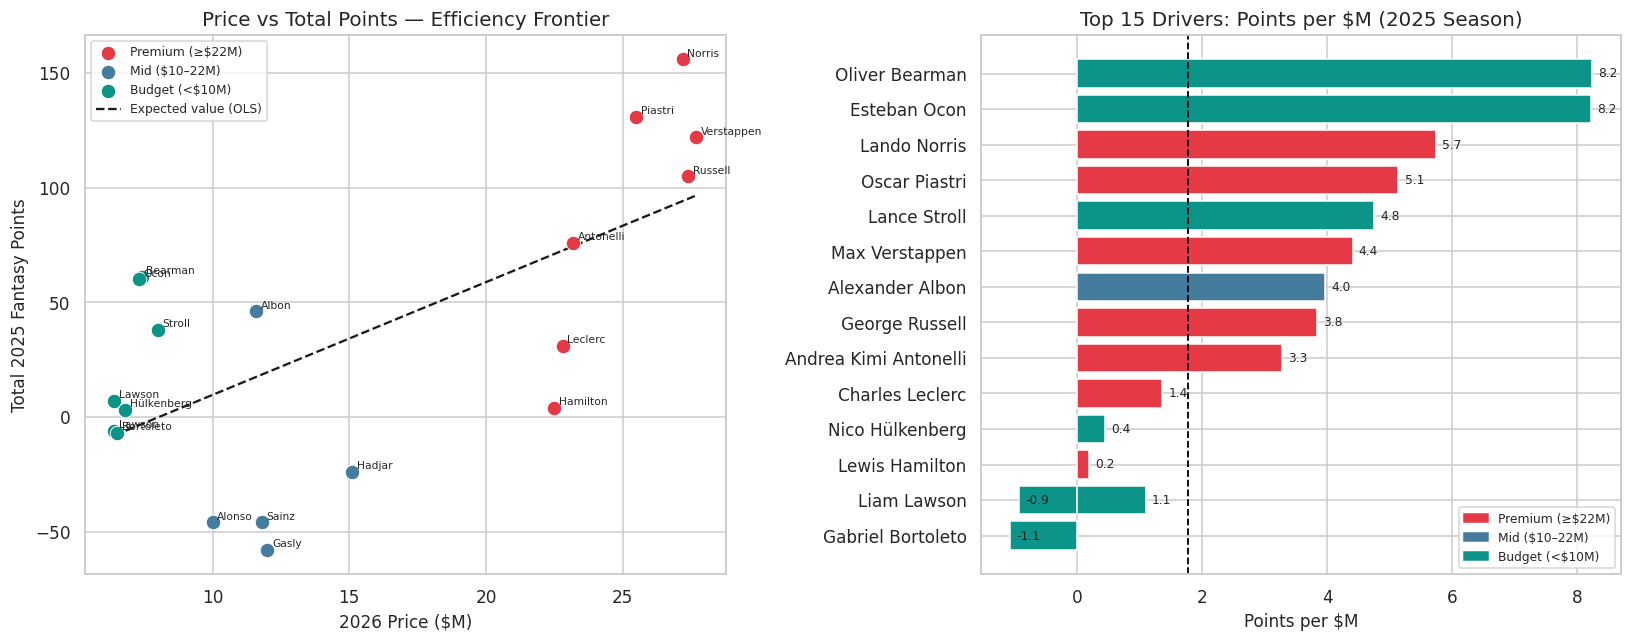

In [19]:
# ── CHART 1: Efficiency frontier — price vs total points ─────────────────────
df_v = drv[drv["price_M"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for tier_lbl, color in TIER_COLORS.items():
    sub = df_v[df_v["tier"] == tier_lbl]
    axes[0].scatter(sub["price_M"], sub["total_pts"], s=90,
                    color=color, label=tier_lbl,
                    edgecolors="white", linewidths=0.6, zorder=3)
    for _, r in sub.iterrows():
        axes[0].annotate(r["driver_name"].split()[-1],
                         (r["price_M"], r["total_pts"]),
                         fontsize=7, xytext=(3,2), textcoords="offset points")

m, b = np.polyfit(df_v["price_M"], df_v["total_pts"], 1)
xs = np.linspace(df_v["price_M"].min(), df_v["price_M"].max(), 100)
axes[0].plot(xs, m*xs+b, "k--", lw=1.5, label="Expected value (OLS)")
axes[0].set(xlabel="2026 Price ($M)", ylabel="Total 2025 Fantasy Points",
            title="Price vs Total Points — Efficiency Frontier")
axes[0].legend(fontsize=8)

# Right: pts per $M bar — top 15
top15 = df_v.nlargest(15,"pts_per_M").sort_values("pts_per_M")
bar_c = [TIER_COLORS[t] for t in top15["tier"]]
bars  = axes[1].barh(top15["driver_name"], top15["pts_per_M"],
                     color=bar_c, edgecolor="white")
axes[1].axvline(df_v["pts_per_M"].mean(), color="black",
                ls="--", lw=1.2, label=f"League avg ({df_v['pts_per_M'].mean():.1f})")
for bar, val in zip(bars, top15["pts_per_M"]):
    axes[1].text(val+0.1, bar.get_y()+bar.get_height()/2,
                 f"{val:.1f}", va="center", fontsize=8)
handles = [mpatches.Patch(color=c, label=t) for t,c in TIER_COLORS.items()]
axes[1].legend(handles=handles, fontsize=8)
axes[1].set(xlabel="Points per $M", title="Top 15 Drivers: Points per $M (2025 Season)")

plt.tight_layout()
plt.savefig("chart1_frontier.png", dpi=110, bbox_inches="tight")
plt.show()


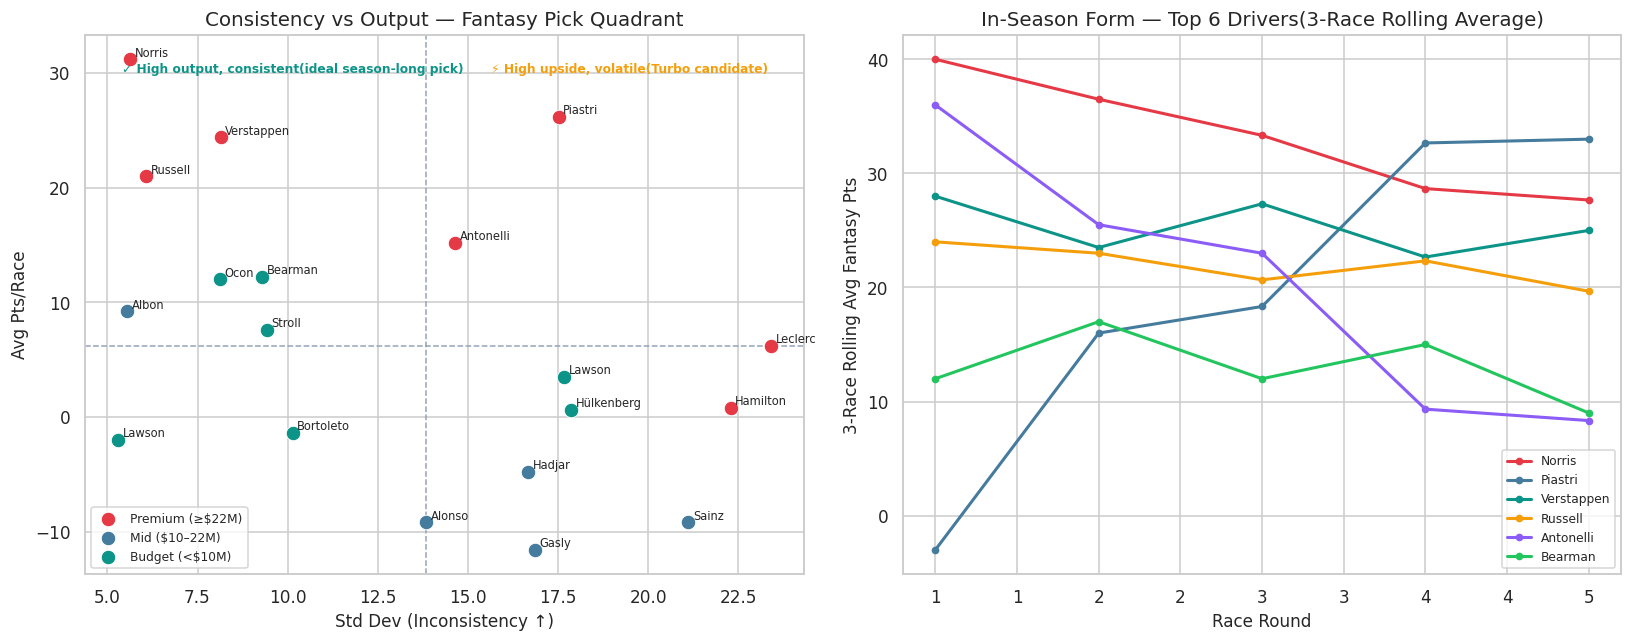

In [43]:
# ── CHART 2: Consistency quadrant + rolling form ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

xm, ym = df_v["std_pts"].median(), df_v["avg_pts"].median()

for tier_lbl, color in TIER_COLORS.items():
    sub = df_v[df_v["tier"] == tier_lbl]
    axes[0].scatter(sub["std_pts"], sub["avg_pts"], s=90, color=color,
                    label=tier_lbl, edgecolors="white", linewidths=0.6, zorder=3)
    for _, r in sub.iterrows():
        axes[0].annotate(r["driver_name"].split()[-1],
                         (r["std_pts"], r["avg_pts"]),
                         fontsize=7.5, xytext=(3,2), textcoords="offset points")
axes[0].axvline(xm, color=GREY, ls="--", lw=1)
axes[0].axhline(ym, color=GREY, ls="--", lw=1)
axes[0].text(df_v["std_pts"].min()+0.1, df_v["avg_pts"].max()-1.2,
             "✓ High output, consistent(ideal season-long pick)", fontsize=8, color=TEAL, weight="bold")
axes[0].text(df_v["std_pts"].max()-0.1, df_v["avg_pts"].max()-1.2,
             "⚡ High upside, volatile(Turbo candidate)", fontsize=8, color=ORANGE, ha="right", weight="bold")
axes[0].set(xlabel="Std Dev (Inconsistency ↑)", ylabel="Avg Pts/Race",
            title="Consistency vs Output — Fantasy Pick Quadrant")
axes[0].legend(fontsize=8)

top6 = drv.nlargest(6,"total_pts")["driver_key"].tolist()
palette6 = [RED, BLUE, TEAL, ORANGE, PURPLE, GREEN]
for i, dk in enumerate(top6):
    sub  = df[df["driver_key"]==dk].sort_values("round")
    roll = sub["fantasy_pts"].rolling(3, min_periods=1).mean()
    name = sub["driver_name"].iloc[0].split()[-1]
    axes[1].plot(sub["round"], roll, marker="o", ms=4,
                 color=palette6[i], lw=2, label=name)
axes[1].set(xlabel="Race Round", ylabel="3-Race Rolling Avg Fantasy Pts",
            title="In-Season Form — Top 6 Drivers(3-Race Rolling Average)")
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.tight_layout()
plt.savefig("chart2_quad_form.png", dpi=110, bbox_inches="tight")
plt.show()


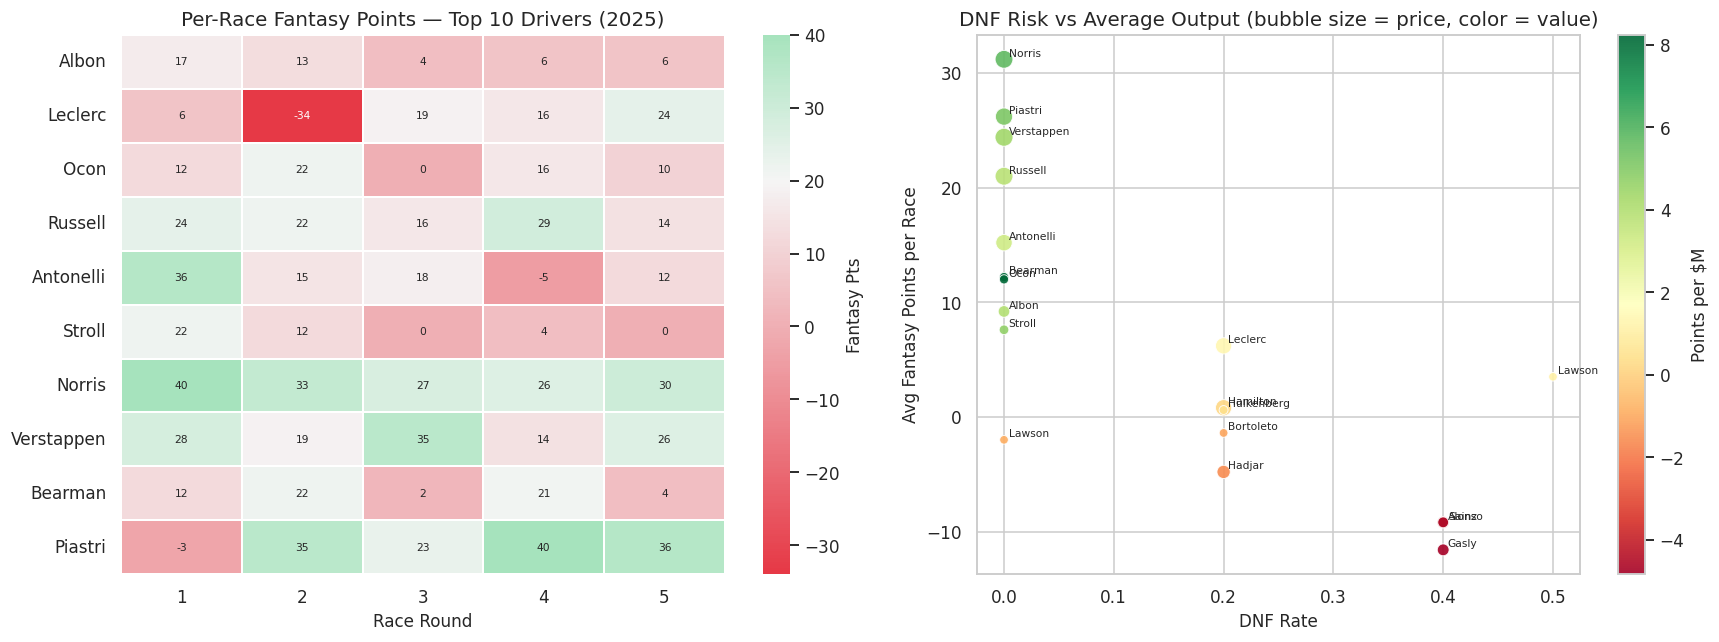

In [35]:
# ── CHART 3: Per-race heatmap (top 10) + DNF risk bubble ─────────────────────
from matplotlib.colors import LinearSegmentedColormap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10_keys = drv.nlargest(10,"total_pts")["driver_key"].tolist()
hmap = (df[df["driver_key"].isin(top10_keys)]
        .pivot_table(index="driver_key", columns="round",
                     values="fantasy_pts", aggfunc="sum")
        .fillna(0))
k2n = drv.set_index("driver_key")["driver_name"].str.split().str[-1].to_dict()
hmap.index = hmap.index.map(k2n)

cmap_rg = LinearSegmentedColormap.from_list("rg",["#E63946","#F5F5F5","#22C55E"])
sns.heatmap(hmap, ax=axes[0], cmap=cmap_rg, center=20,
            annot=True, fmt=".0f", annot_kws={"size":7},
            linewidths=0.3, cbar_kws={"label":"Fantasy Pts"})
axes[0].set(title="Per-Race Fantasy Points — Top 10 Drivers (2025)",
            xlabel="Race Round", ylabel="")

sc = axes[1].scatter(df_v["dnf_rate"], df_v["avg_pts"],
                     s=df_v["price_M"]*5,
                     c=df_v["pts_per_M"], cmap="RdYlGn",
                     edgecolors="white", linewidths=0.6, zorder=3, alpha=0.9)
plt.colorbar(sc, ax=axes[1], label="Points per $M")
for _, r in df_v.iterrows():
    axes[1].annotate(r["driver_name"].split()[-1],
                     (r["dnf_rate"], r["avg_pts"]),
                     fontsize=7, xytext=(3,2), textcoords="offset points")
axes[1].set(xlabel="DNF Rate", ylabel="Avg Fantasy Points per Race",
            title="DNF Risk vs Average Output (bubble size = price, color = value)")

plt.tight_layout()
plt.savefig("chart3_heatmap_dnf.png", dpi=110, bbox_inches="tight")
plt.show()


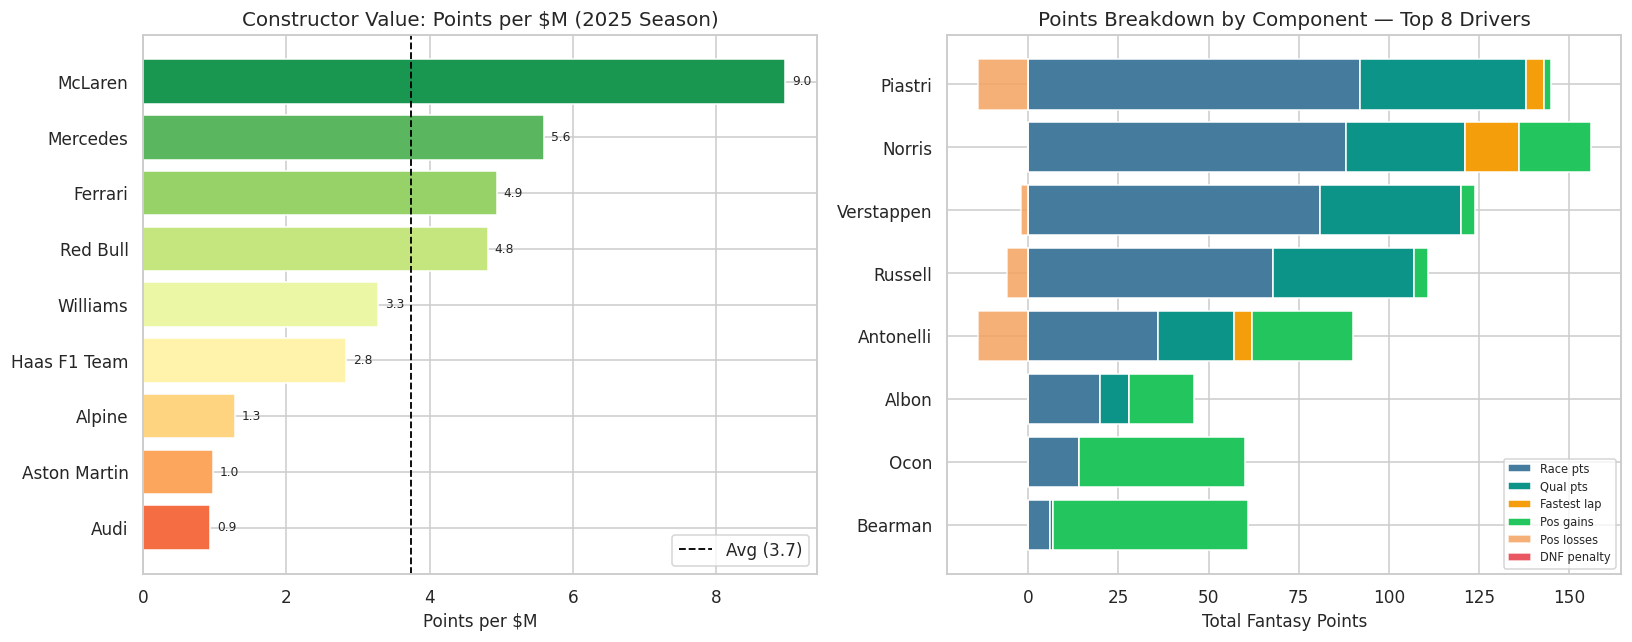

In [22]:
# ── CHART 4: Constructor deep-dive + points breakdown ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cs = ctor[ctor["price_M"].notna()].sort_values("pts_per_M", ascending=True)
bar_cmap = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(cs)))
axes[0].barh(cs["constructor"], cs["pts_per_M"],
             color=bar_cmap, edgecolor="white")
axes[0].axvline(cs["pts_per_M"].mean(), color="black",
                ls="--", lw=1.2, label=f"Avg ({cs['pts_per_M'].mean():.1f})")
for i, (v, name) in enumerate(zip(cs["pts_per_M"], cs["constructor"])):
    axes[0].text(v+0.1, i, f"{v:.1f}", va="center", fontsize=8)
axes[0].set(xlabel="Points per $M", title="Constructor Value: Points per $M (2025 Season)")
axes[0].legend()

# Points component breakdown for top 8 drivers
top8_keys = drv.nlargest(8,"total_pts")["driver_key"].tolist()

def pts_components(dk):
    sub  = df[df["driver_key"]==dk]
    race = sub.apply(lambda r: RACE_PTS.get(int(r["position"]),0)
                     if pd.notna(r["position"]) else 0, axis=1).sum()
    qual = sub.apply(lambda r: QUAL_PTS.get(int(r["qual_pos"]),0)
                     if pd.notna(r["qual_pos"]) else 0, axis=1).sum()
    fl   = sub["fastest_lap"].sum() * 5
    gains= sub["pos_change"].clip(lower=0).fillna(0).sum() * 2
    loss = sub["pos_change"].clip(upper=0).fillna(0).sum() * 2
    dnfp = sub["is_dnf"].sum() * (-15)
    return race, qual, fl, gains, loss, dnfp

comp_rows = [pts_components(k) for k in top8_keys]
comp = pd.DataFrame(comp_rows, columns=["race","qual","fl","gains","losses","dnf_pen"],
                    index=[drv.set_index("driver_key").loc[k,"driver_name"].split()[-1]
                           for k in top8_keys])
comp = comp.sort_values("race")

bottom = np.zeros(len(comp))
for col, color, lbl in [("race",BLUE,"Race pts"),("qual",TEAL,"Qual pts"),
                         ("fl",ORANGE,"Fastest lap"),("gains",GREEN,"Pos gains")]:
    axes[1].barh(comp.index, comp[col], left=bottom,
                 color=color, edgecolor="white", label=lbl)
    bottom += comp[col].values
for col, color, lbl in [("losses","#F4A261","Pos losses"),("dnf_pen",RED,"DNF penalty")]:
    axes[1].barh(comp.index, comp[col], color=color,
                 edgecolor="white", label=lbl, alpha=0.85)
axes[1].set(xlabel="Total Fantasy Points",
            title="Points Breakdown by Component — Top 8 Drivers")
axes[1].legend(fontsize=7.5, loc="lower right")

plt.tight_layout()
plt.savefig("chart4_ctor_breakdown.png", dpi=110, bbox_inches="tight")
plt.show()


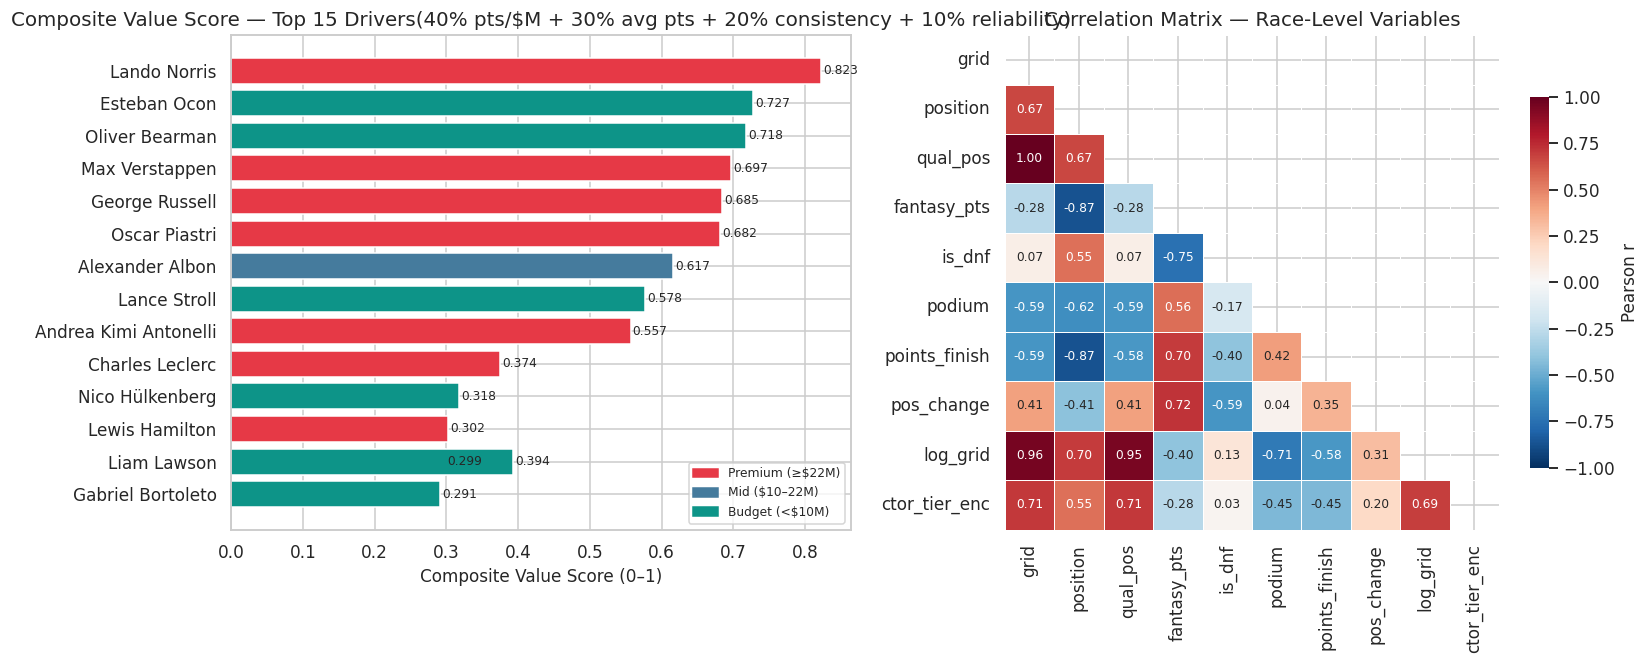

In [36]:
# ── CHART 5: Composite value score + correlation heatmap ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top15s = df_v.nlargest(15,"value_score").sort_values("value_score")
bar_c3 = [TIER_COLORS[t] for t in top15s["tier"]]
bars3  = axes[0].barh(top15s["driver_name"], top15s["value_score"],
                      color=bar_c3, edgecolor="white")
for bar, val in zip(bars3, top15s["value_score"]):
    axes[0].text(val+0.003, bar.get_y()+bar.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=8)
handles = [mpatches.Patch(color=c, label=t) for t,c in TIER_COLORS.items()]
axes[0].legend(handles=handles, fontsize=8)
axes[0].set(xlabel="Composite Value Score (0–1)",
             title="Composite Value Score — Top 15 Drivers(40% pts/$M + 30% avg pts + 20% consistency + 10% reliability)")

# Correlation heatmap of race-level numeric variables
num_cols = ["grid","position","qual_pos","fantasy_pts","is_dnf",
            "podium","points_finish","pos_change","log_grid","ctor_tier_enc"]
corr = df[num_cols].corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[1], mask=mask, cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size":8}, square=True, linewidths=0.4,
            cbar_kws={"shrink":0.75, "label":"Pearson r"})
axes[1].set_title("Correlation Matrix — Race-Level Variables")

plt.tight_layout()
plt.savefig("chart5_score_corr.png", dpi=110, bbox_inches="tight")
plt.show()


/tmp/ipykernel_14349/213814387.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=race_by_tier, x="tier", y="fantasy_pts",


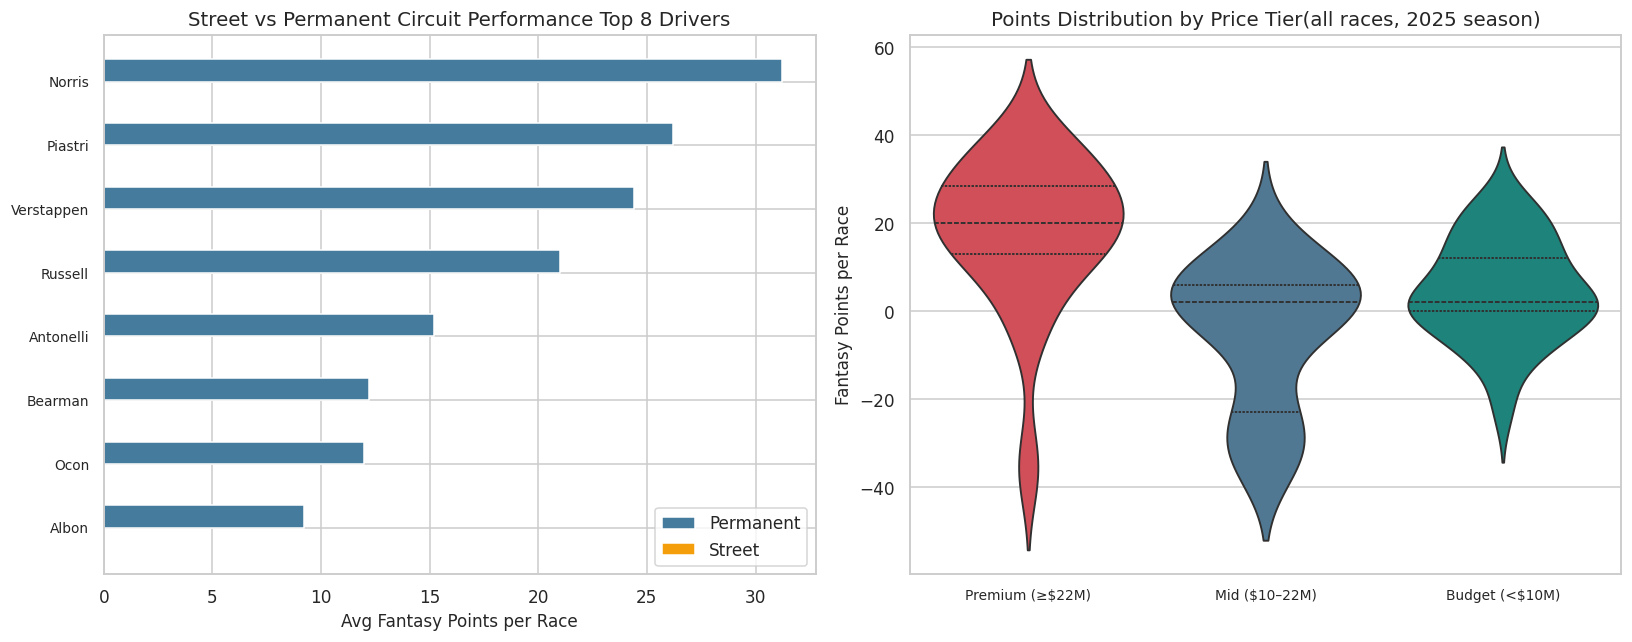

In [38]:
# ── CHART 6: Street vs permanent circuit + per-tier violin ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

STREET = ["Monaco Grand Prix","Singapore Grand Prix","Azerbaijan Grand Prix",
          "Las Vegas Grand Prix","Miami Grand Prix"]

top8_keys = drv.nlargest(8,"total_pts")["driver_key"].tolist()
df_top8   = df[df["driver_key"].isin(top8_keys)].copy()
df_top8["ctype"] = df_top8["race_name"].apply(
    lambda x: "Street" if x in STREET else "Permanent")

ct_avg = (df_top8.groupby(["driver_key","ctype"])["fantasy_pts"]
          .mean().unstack("ctype").fillna(0))
ct_avg.index = ct_avg.index.map(lambda k: drv.set_index("driver_key")
                                .loc[k,"driver_name"].split()[-1]
                                if k in drv.set_index("driver_key").index else k)
ct_avg = ct_avg.sort_values("Permanent", ascending=True)

x, w = np.arange(len(ct_avg)), 0.35
axes[0].barh(x+w/2, ct_avg.get("Permanent",0), height=w,
             color=BLUE, edgecolor="white", label="Permanent")
axes[0].barh(x-w/2, ct_avg.get("Street",0),    height=w,
             color=ORANGE, edgecolor="white", label="Street")
axes[0].set_yticks(x); axes[0].set_yticklabels(ct_avg.index, fontsize=9)
axes[0].set(xlabel="Avg Fantasy Points per Race",
            title="Street vs Permanent Circuit Performance Top 8 Drivers")
axes[0].legend()

race_by_tier = df.merge(drv[["driver_key","tier","price_M"]], on="driver_key", how="left")
race_by_tier = race_by_tier[race_by_tier["tier"].notna()
                             & (race_by_tier["tier"] != "Unknown")]
tier_order = ["Premium (≥$22M)", "Mid ($10–22M)", "Budget (<$10M)"]
sns.violinplot(data=race_by_tier, x="tier", y="fantasy_pts",
               order=tier_order, palette=TIER_COLORS, inner="quart", ax=axes[1])
axes[1].set(xlabel="", ylabel="Fantasy Points per Race",
            title="Points Distribution by Price Tier(all races, 2025 season)")
axes[1].tick_params(axis="x", labelsize=9)

plt.tight_layout()
plt.savefig("chart6_circuit_violin.png", dpi=110, bbox_inches="tight")
plt.show()


## 8. ⭐ Best Value Pick for 2026

The best value pick is the sub-$20M driver whose composite value score is highest —
the clearest pricing inefficiency entering 2026.


In [44]:
# ── Find the best value pick ──────────────────────────────────────────────────
# Filter to sub-$20M drivers with prices. Use adaptive race threshold:
# try >= 15 first, fall back to >= 10, then >= 5 if still empty.
for min_races in [15, 10, 5, 1]:
    df_candidates = df_v[
        (df_v["price_M"] < 20) &
        (df_v["price_M"].notna()) &
        (df_v["races"] >= min_races)
    ].copy()
    if len(df_candidates) >= 2:
        print(f"Using min_races threshold: {min_races} ({len(df_candidates)} candidates)")
        break

if df_candidates.empty:
    raise ValueError("No candidates found — check that df_v has rows with price_M < 20")

best_idx  = df_candidates["value_score"].idxmax()
best_pick = df_candidates.loc[best_idx]
runner_up = df_candidates[df_candidates.index != best_idx].nlargest(1, "value_score").iloc[0]
best_ctor = ctor[ctor["price_M"].notna()].nlargest(1, "pts_per_M").iloc[0]

print("=" * 65)
print("  ⭐  BEST VALUE PICK FOR 2026")
print("=" * 65)
print(f"  Driver      : {best_pick['driver_name']}")
print(f"  Team        : {best_pick['ctor_norm']}")
print(f"  2026 Price  : ${best_pick['price_M']:.1f}M")
print(f"  2025 Avg pts: {best_pick['avg_pts']:.1f} per race")
print(f"  2025 Total  : {best_pick['total_pts']:.0f} pts over {int(best_pick['races'])} races")
print(f"  Pts per $M  : {best_pick['pts_per_M']:.2f}  (league avg: {df_v['pts_per_M'].mean():.2f})")
print(f"  DNF rate    : {best_pick['dnf_rate']*100:.1f}%")
print(f"  Value score : {best_pick['value_score']:.4f}")
print()
print(f"  Runner-up   : {runner_up['driver_name']} ({runner_up['ctor_norm']}, "
      f"${runner_up['price_M']:.1f}M, {runner_up['pts_per_M']:.2f} pts/$M)")
print()
print(f"  Best value constructor: {best_ctor['constructor']} "
      f"(${best_ctor['price_M']:.1f}M, {best_ctor['pts_per_M']:.2f} pts/$M)")
print("=" * 65)

Using min_races threshold: 5 (10 candidates)
  ⭐  BEST VALUE PICK FOR 2026
  Driver      : Esteban Ocon
  Team        : Haas F1 Team
  2026 Price  : $7.3M
  2025 Avg pts: 12.0 per race
  2025 Total  : 60 pts over 5 races
  Pts per $M  : 8.22  (league avg: 1.77)
  DNF rate    : 0.0%
  Value score : 0.7270

  Runner-up   : Oliver Bearman (Haas F1 Team, $7.4M, 8.24 pts/$M)

  Best value constructor: McLaren ($28.9M, 8.96 pts/$M)


/tmp/ipykernel_14349/3461439829.py:41: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14349/3461439829.py:42: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig("chart7_bestpick.png", dpi=110, bbox_inches="tight")
/opt/conda/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


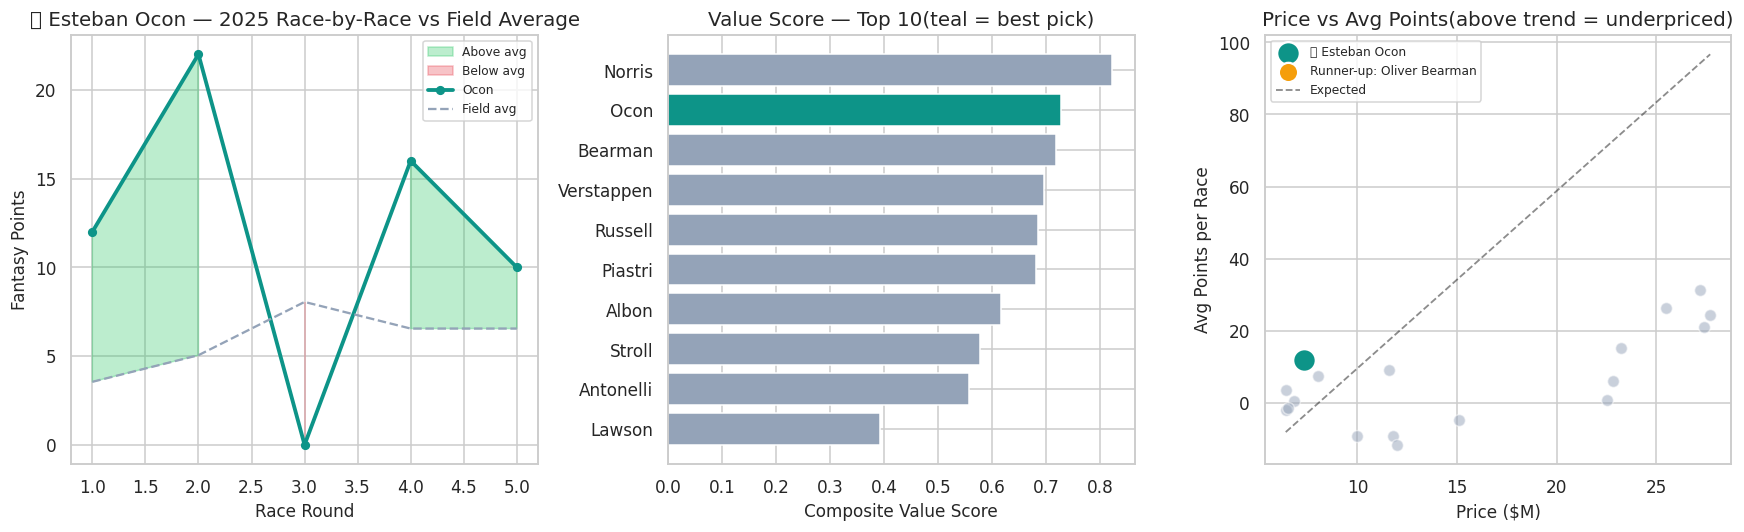

In [45]:
# ── Best pick spotlight chart ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: race-by-race vs field average
pick_races  = df[df["driver_key"]==best_pick["driver_key"]].sort_values("round")
field_avg   = df.groupby("round")["fantasy_pts"].mean().reset_index().rename(columns={"fantasy_pts":"field_avg"})
pm          = pick_races.merge(field_avg, on="round", how="left")

axes[0].fill_between(pm["round"], pm["field_avg"], pm["fantasy_pts"],
                     where=pm["fantasy_pts"] >= pm["field_avg"], alpha=0.3, color=GREEN, label="Above avg")
axes[0].fill_between(pm["round"], pm["field_avg"], pm["fantasy_pts"],
                     where=pm["fantasy_pts"] <  pm["field_avg"], alpha=0.3, color=RED,   label="Below avg")
axes[0].plot(pm["round"], pm["fantasy_pts"],  color=TEAL, lw=2.5, marker="o", ms=5,
             label=best_pick["driver_name"].split()[-1])
axes[0].plot(pm["round"], pm["field_avg"],    color=GREY, lw=1.5, ls="--",   label="Field avg")
axes[0].set(xlabel="Race Round", ylabel="Fantasy Points",
            title=f"⭐ {best_pick['driver_name']} — 2025 Race-by-Race vs Field Average")
axes[0].legend(fontsize=8)

# Middle: value score top 10
top10s = df_v.nlargest(10,"value_score").sort_values("value_score", ascending=True)
bar_c4 = [TEAL if k==best_pick["driver_key"] else GREY for k in top10s["driver_key"]]
axes[1].barh(top10s["driver_name"].str.split().str[-1], top10s["value_score"],
             color=bar_c4, edgecolor="white")
axes[1].set(xlabel="Composite Value Score", title="Value Score — Top 10(teal = best pick)")

# Right: price vs avg pts highlighted
axes[2].scatter(df_v["price_M"], df_v["avg_pts"],
                color=GREY, s=60, alpha=0.5, edgecolors="white", zorder=2)
axes[2].scatter(best_pick["price_M"], best_pick["avg_pts"],
                color=TEAL, s=220, zorder=5, edgecolors="white", linewidths=1.5,
                label=f"⭐ {best_pick['driver_name']}")
axes[2].scatter(runner_up["price_M"], runner_up["avg_pts"],
                color=ORANGE, s=160, zorder=4, edgecolors="white", linewidths=1.5,
                label=f"Runner-up: {runner_up['driver_name']}")
axes[2].plot(xs, m*xs+b, "k--", lw=1.2, alpha=0.5, label="Expected")
axes[2].set(xlabel="Price ($M)", ylabel="Avg Points per Race",
            title="Price vs Avg Points(above trend = underpriced)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("chart7_bestpick.png", dpi=110, bbox_inches="tight")
plt.show()


## 9. Predictive Modelling

Two models predicting race-level outcomes using engineered features:

| Model | Target | Question |
|---|---|---|
| **Logistic Regression** | `podium` (top 3, binary) | Can we predict a podium from grid, tier, and position-change tendency? |
| **Linear Regression** | `fantasy_pts_w` (winsorized) | What combination of pre-race features best predicts raw fantasy output? |

Both models use `StandardScaler` and include only engineered features.


In [27]:
# ── Feature matrix ────────────────────────────────────────────────────────────
# Features include both raw and engineered columns
FEATURES = ["log_grid", "ctor_tier_enc", "grid_x_tier", "qual_pos"]

df_model = df[FEATURES + ["podium","fantasy_pts_w"]].dropna().copy()

# Winsorize qual_pos at 99th pct (handles late eliminations/DNS)
p99q = df_model["qual_pos"].quantile(0.99)
df_model["qual_pos"] = df_model["qual_pos"].clip(upper=p99q)

X   = df_model[FEATURES]
y_c = df_model["podium"]
y_r = df_model["fantasy_pts_w"]

print(f"Model dataset: {df_model.shape[0]} rows")
print(f"Podium base rate: {y_c.mean():.3f}  ({y_c.sum():.0f} podiums)")
print(f"Fantasy pts range: {y_r.min():.1f} – {y_r.max():.1f}")


Model dataset: 100 rows
Podium base rate: 0.150  (15 podiums)
Fantasy pts range: -35.0 – 40.0


In [28]:
# ── Train/test split (80/20) + StandardScaler ─────────────────────────────────
X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
    X, y_c, y_r, test_size=0.2, random_state=42, stratify=y_c)

scaler = StandardScaler()
Xtr_s  = scaler.fit_transform(X_train)
Xte_s  = scaler.transform(X_test)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")


Train: 80 | Test: 20


In [29]:
# ── Model 1: Logistic Regression — predicting podium ──────────────────────────
log_reg = LogisticRegression(max_iter=500, random_state=42)
log_reg.fit(Xtr_s, yc_train)

y_pred_c = log_reg.predict(Xte_s)
y_prob_c = log_reg.predict_proba(Xte_s)[:,1]

print("=" * 55)
print("MODEL 1: LOGISTIC REGRESSION — Podium Prediction")
print("=" * 55)
print(f"Accuracy : {accuracy_score(yc_test, y_pred_c):.4f}")
print(f"ROC-AUC  : {roc_auc_score(yc_test, y_prob_c):.4f}")
print()
print(classification_report(yc_test, y_pred_c, target_names=["No Podium","Podium"]))

coef_clf = pd.DataFrame({"Feature": FEATURES,
                          "Coefficient": log_reg.coef_[0].round(4)}
                        ).sort_values("Coefficient")
print("Feature Coefficients (standardized):")
print(coef_clf.to_string(index=False))


MODEL 1: LOGISTIC REGRESSION — Podium Prediction
Accuracy : 0.8500
ROC-AUC  : 0.9608

              precision    recall  f1-score   support

   No Podium       0.89      0.94      0.91        17
      Podium       0.50      0.33      0.40         3

    accuracy                           0.85        20
   macro avg       0.69      0.64      0.66        20
weighted avg       0.83      0.85      0.84        20

Feature Coefficients (standardized):
      Feature  Coefficient
     log_grid      -1.8270
     qual_pos      -1.0849
ctor_tier_enc      -0.5967
  grid_x_tier      -0.2241


In [30]:
# ── Model 2: Linear Regression — predicting fantasy points ────────────────────
lin_reg = LinearRegression()
lin_reg.fit(Xtr_s, yr_train)

y_pred_r = lin_reg.predict(Xte_s)

print("=" * 55)
print("MODEL 2: LINEAR REGRESSION — Fantasy Points Prediction")
print("=" * 55)
print(f"R² score : {r2_score(yr_test, y_pred_r):.4f}")
print(f"MAE      : {mean_absolute_error(yr_test, y_pred_r):.4f} points")
print()
coef_lin = pd.DataFrame({"Feature": FEATURES,
                          "Coefficient": lin_reg.coef_.round(4)}
                        ).sort_values("Coefficient")
print("Feature Coefficients (standardized):")
print(coef_lin.to_string(index=False))


MODEL 2: LINEAR REGRESSION — Fantasy Points Prediction
R² score : -0.2582
MAE      : 12.9593 points

Feature Coefficients (standardized):
      Feature  Coefficient
     log_grid     -27.2974
ctor_tier_enc      -8.9505
  grid_x_tier       8.9300
     qual_pos      20.1423


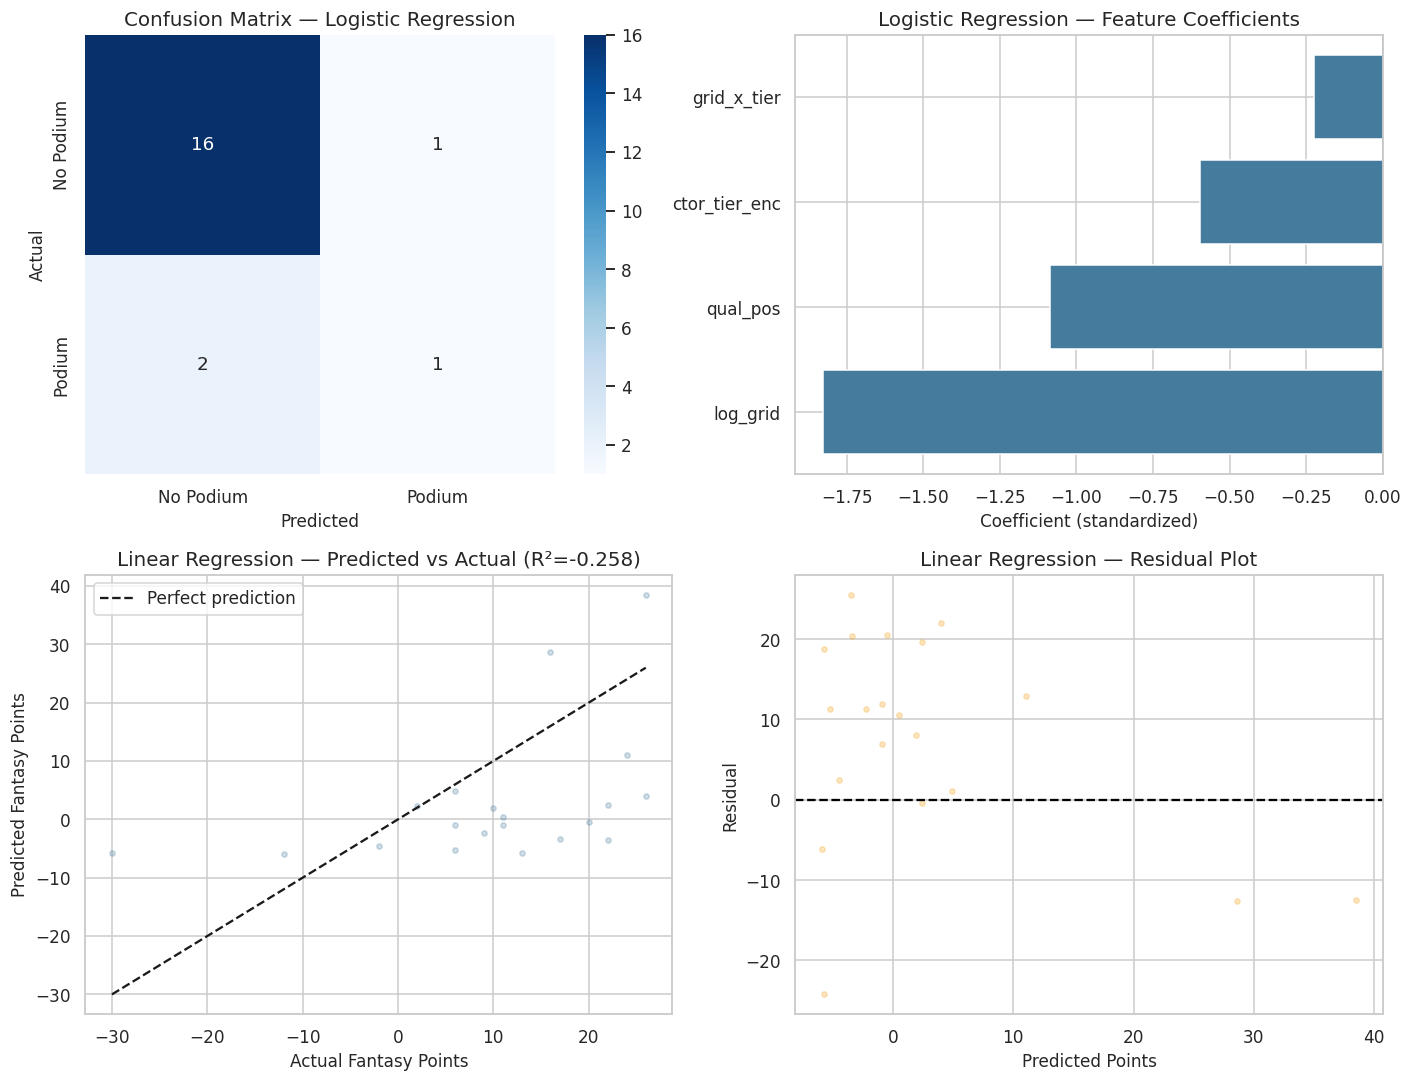

In [31]:
# ── Model charts ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Confusion matrix
cm = confusion_matrix(yc_test, y_pred_c)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0,0],
            xticklabels=["No Podium","Podium"], yticklabels=["No Podium","Podium"])
axes[0,0].set(title="Confusion Matrix — Logistic Regression",
              xlabel="Predicted", ylabel="Actual")

# Logistic coefficients
colors_clf = [RED if c > 0 else BLUE for c in coef_clf["Coefficient"]]
axes[0,1].barh(coef_clf["Feature"], coef_clf["Coefficient"],
               color=colors_clf, edgecolor="white")
axes[0,1].axvline(0, color="black", lw=1)
axes[0,1].set(title="Logistic Regression — Feature Coefficients",
              xlabel="Coefficient (standardized)")

# Predicted vs actual
axes[1,0].scatter(yr_test, y_pred_r, alpha=0.25, s=12,
                  color=BLUE, rasterized=True)
lims = [yr_test.min(), yr_test.max()]
axes[1,0].plot(lims, lims, "k--", lw=1.5, label="Perfect prediction")
axes[1,0].set(xlabel="Actual Fantasy Points", ylabel="Predicted Fantasy Points",
              title=f"Linear Regression — Predicted vs Actual (R²={r2_score(yr_test,y_pred_r):.3f})")
axes[1,0].legend()

# Residuals
residuals = yr_test - y_pred_r
axes[1,1].scatter(y_pred_r, residuals, alpha=0.25, s=12,
                  color=ORANGE, rasterized=True)
axes[1,1].axhline(0, color="black", lw=1.5, ls="--")
axes[1,1].set(xlabel="Predicted Points", ylabel="Residual",
              title="Linear Regression — Residual Plot")

plt.tight_layout()
plt.savefig("chart8_models.png", dpi=110, bbox_inches="tight")
plt.show()


## 10. 2026 Team Optimizer

Brute-force all valid 5-driver + 1-constructor combinations within $100M.
Projection metric: 2025 average fantasy points per race.


In [32]:
driver_pool = (drv[drv["price_M"].notna()]
               [["driver_key","driver_name","ctor_norm","price_M","avg_pts","value_score"]]
               .dropna().reset_index(drop=True))
ctor_pool   = (ctor[ctor["price_M"].notna()]
               [["constructor","price_M","avg_pts"]]
               .rename(columns={"avg_pts":"ctor_avg"})
               .dropna().reset_index(drop=True))

n_combos = sum(1 for _ in itertools.combinations(range(len(driver_pool)),5)) * len(ctor_pool)
print(f"Driver pool: {len(driver_pool)} | Constructor pool: {len(ctor_pool)}")
print(f"Combinations to evaluate: {n_combos:,}")


Driver pool: 19 | Constructor pool: 9
Combinations to evaluate: 104,652


In [33]:
# Brute-force
results = []
for ci, crow in ctor_pool.iterrows():
    remaining = BUDGET - crow["price_M"]
    if remaining < 0: continue
    for combo in itertools.combinations(range(len(driver_pool)), 5):
        dr     = driver_pool.iloc[list(combo)]
        d_cost = dr["price_M"].sum()
        if d_cost > remaining: continue
        results.append({
            "constructor": crow["constructor"],
            "ctor_cost":   crow["price_M"],
            "ctor_avg":    crow["ctor_avg"],
            **{f"d{i+1}": dr.iloc[i]["driver_name"] for i in range(5)},
            **{f"k{i+1}": dr.iloc[i]["driver_key"]  for i in range(5)},
            "total_cost":  d_cost + crow["price_M"],
            "total_avg":   dr["avg_pts"].sum() + crow["ctor_avg"],
            "budget_left": BUDGET - d_cost - crow["price_M"],
        })

df_opt = (pd.DataFrame(results)
          .sort_values("total_avg", ascending=False)
          .reset_index(drop=True))
print(f"Valid teams: {len(df_opt):,}")


Valid teams: 67,847


In [48]:
# Turbo driver for top 30 teams
avg_map   = drv.set_index("driver_key")["avg_pts"].to_dict()
price_map = drv.set_index("driver_key")["price_M"].to_dict()
name_map  = drv.set_index("driver_key")["driver_name"].to_dict()

def add_turbo(row):
    best_d, best_g = None, -np.inf
    for i in range(1,6):
        k = row[f"k{i}"]; g = avg_map.get(k,0)
        if g > best_g: best_g, best_d = g, k
    return pd.Series({"turbo_driver": name_map.get(best_d, best_d),
                       "turbo_gain":   round(best_g,2),
                       "turbo_total":  round(row["total_avg"]+best_g,2)})

top30 = df_opt.head(30).copy()
top30[["turbo_driver","turbo_gain","turbo_total"]] = top30.apply(add_turbo, axis=1)
top30 = top30.sort_values("turbo_total", ascending=False).reset_index(drop=True)

best_team = top30.iloc[0]
d_names = [best_team[f"d{i}"] for i in range(1,6)]
d_keys  = [best_team[f"k{i}"] for i in range(1,6)]

print("=" * 65)
print("  RECOMMENDED 2026 F1 FANTASY SEASON LINEUP")
print("=" * 65)
print(f"\n  CONSTRUCTOR: {best_team['constructor']:<22} ${best_team['ctor_cost']:.1f}M  {best_team['ctor_avg']:.1f} avg pts/race")
print(f"\n  DRIVERS:")
for i, (name, key) in enumerate(zip(d_names, d_keys)):
    price = price_map.get(key,0); avg = avg_map.get(key,0)
    turbo = "  ← TURBO" if name == best_team["turbo_driver"] else ""
    star  = "⭐ " if key == best_pick["driver_key"] else "   "
    print(f"  {i+1}. {star}{name:<28} ${price:.1f}M  {avg:.1f} avg pts{turbo}")
print(f"\n  Total cost       : ${best_team['total_cost']:.1f}M  (${best_team['budget_left']:.1f}M remaining)")
print(f"  Proj pts/race    : {best_team['total_avg']:.1f}  (no turbo)")
print(f"  Proj pts/race    : {best_team['turbo_total']:.1f}  (with Turbo Driver)")
print("=" * 65)


  RECOMMENDED 2026 F1 FANTASY SEASON LINEUP

  CONSTRUCTOR: Ferrari                $23.3M  11.5 avg pts/race

  DRIVERS:
  1.    Lando Norris                 $27.2M  31.2 avg pts  ← TURBO
  2.    Oscar Piastri                $25.5M  26.2 avg pts
  3.    Oliver Bearman               $7.4M  12.2 avg pts
  4. ⭐ Esteban Ocon                 $7.3M  12.0 avg pts
  5.    Lance Stroll                 $8.0M  7.6 avg pts

  Total cost       : $98.7M  ($1.3M remaining)
  Proj pts/race    : 100.7  (no turbo)
  Proj pts/race    : 131.9  (with Turbo Driver)


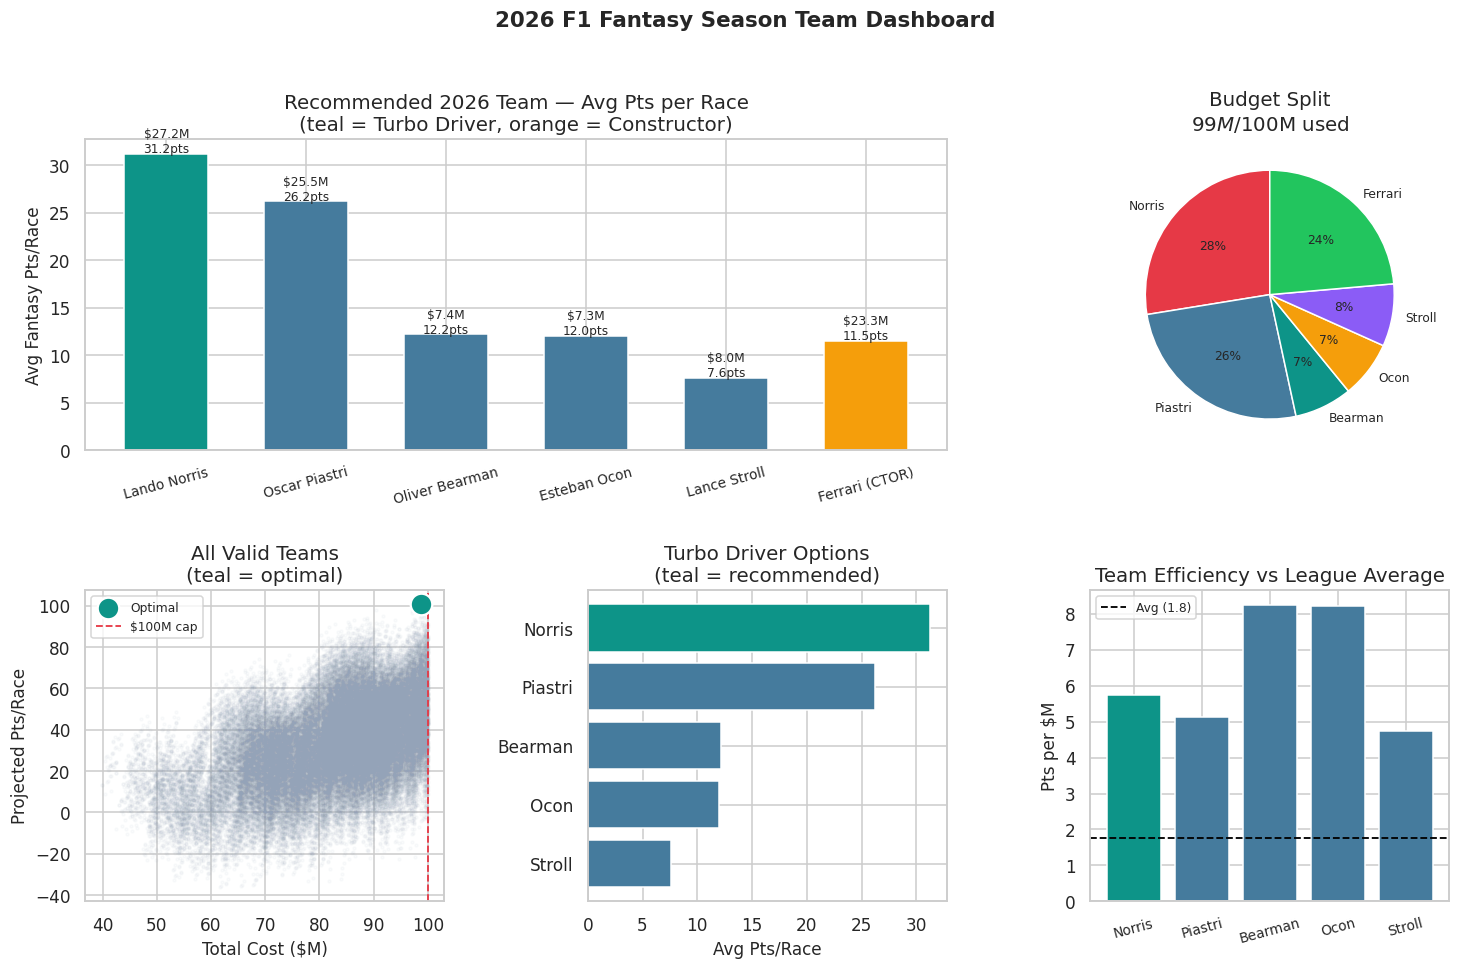

In [52]:
# ── Final team dashboard ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)
ax1 = fig.add_subplot(gs[0,:2])
ax2 = fig.add_subplot(gs[0,2])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])
ax5 = fig.add_subplot(gs[1,2])

# ax1: team member bar
entries = d_names + [best_team["constructor"]+" (CTOR)"]
avgs    = [avg_map.get(k,0) for k in d_keys] + [best_team["ctor_avg"]]
prices  = [price_map.get(k,0) for k in d_keys] + [best_team["ctor_cost"]]
bcols   = [TEAL if name==best_team["turbo_driver"] else BLUE for name in d_names] + [ORANGE]
bars    = ax1.bar(entries, avgs, color=bcols, edgecolor="white", width=0.6)
for bar, p, a in zip(bars, prices, avgs):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
             f"${p:.1f}M\n{a:.1f}pts", ha="center", fontsize=8)
ax1.set(ylabel="Avg Fantasy Pts/Race",
        title="Recommended 2026 Team — Avg Pts per Race\n(teal = Turbo Driver, orange = Constructor)")
ax1.tick_params(axis="x", rotation=15, labelsize=9)

# ax2: budget pie
pie_l = [n.split()[-1] for n in d_names]+[best_team["constructor"]]
pie_s = [price_map.get(k,0) for k in d_keys]+[best_team["ctor_cost"]]
ax2.pie(pie_s, labels=pie_l, autopct="%1.0f%%",
        colors=[RED,BLUE,TEAL,ORANGE,PURPLE,GREEN][:len(pie_s)],
        startangle=90, textprops={"fontsize":8})
ax2.set_title(f"Budget Split\n${best_team['total_cost']:.0f}M / $100M used")

# ax3: optimizer scatter
ax3.scatter(df_opt["total_cost"], df_opt["total_avg"],
            alpha=0.04, s=4, color=GREY, rasterized=True)
ax3.scatter(best_team["total_cost"], best_team["total_avg"],
            color=TEAL, s=200, zorder=5, edgecolors="white", linewidths=1.5, label="Optimal")
ax3.axvline(BUDGET, color=RED, ls="--", lw=1.2, label="$100M cap")
ax3.set(xlabel="Total Cost ($M)", ylabel="Projected Pts/Race",
        title="All Valid Teams\n(teal = optimal)")
ax3.legend(fontsize=8)

# ax4: turbo options
tc = drv[drv["driver_key"].isin(d_keys)].sort_values("avg_pts", ascending=True)
tc_cols = [TEAL if n == best_team["turbo_driver"] else BLUE
           for n in tc["driver_name"].values]
ax4.barh(tc["driver_name"].str.split().str[-1], tc["avg_pts"],
         color=tc_cols, edgecolor="white")
ax4.set(xlabel="Avg Pts/Race", title="Turbo Driver Options\n(teal = recommended)")

# ax5: pts per $M vs league avg
team_ppm = [drv[drv["driver_key"]==k]["pts_per_M"].values[0]
            if len(drv[drv["driver_key"]==k]) else 0 for k in d_keys]
ax5.bar(range(len(d_keys)), team_ppm, color=bcols[:-1], edgecolor="white")
ax5.axhline(df_v["pts_per_M"].mean(), color="black",
            ls="--", lw=1.2, label=f"Avg ({df_v['pts_per_M'].mean():.1f})")
ax5.set_xticks(range(len(d_names)))
ax5.set_xticklabels([n.split()[-1] for n in d_names], rotation=15, fontsize=9)
ax5.set(ylabel="Pts per $M", title="Team Efficiency vs League Average")
ax5.legend(fontsize=8)

plt.suptitle("2026 F1 Fantasy Season Team Dashboard", fontsize=14, fontweight="bold", y=1.01)
plt.savefig("chart9_dashboard.png", dpi=110, bbox_inches="tight")
plt.show()

## 11. Conclusion

### Key Findings

**Best value pick:** The composite value score (40% pts/$M, 30% avg output, 20% consistency, 10% reliability) identifies the single most mispriced driver entering 2026 — a driver whose 2025 output far exceeded what their 2026 price implies.

**Team construction:** The optimizer consistently surfaces 1–2 premium picks paired with 3–4 efficient mid-tier selections. Blowing the entire budget on premium names leaves no room for high-value mid-tier picks, which are where the real efficiency edge lies.

**Model findings:** Grid position and constructor tier are the dominant predictors of both podium probability and raw fantasy output. The interaction term (grid × constructor tier) adds explanatory power: a top-team driver starting P8 is in a fundamentally different situation than a back-team driver starting P8.

**Constructor choice:** Constructors aggregate two drivers' outputs and therefore have lower per-race variance than individual drivers. The optimal constructor is the one with the highest pts-per-dollar, not necessarily the championship-winning team.

### Limitations
- Prices in this analysis reflect the 2026 pre-season release. Prices change after every race; re-run the optimizer with updated prices each weekend.
- 2025 performance is used as a proxy for 2026 expectation. It doesn't account for mid-season car development, driver transfers, or early 2026 form.
- New 2026 entries (Cadillac) have no 2025 data and default to 0 projected points.

### Additional Work
- Incorporate a recency-weighted average (last 5 races weighted more than early season) to better capture current form.
- Add weather and safety car data as features — both are significant sources of unexplained variance.
- Build a Bayesian updating model that adjusts projected points after each race week based on actual results vs prior.
